### 0. Importaciones

In [ ]:
# pip install scikit-learn xgboost
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

# MLOps
from pycaret.classification import *
# ML Al
from sklearn.model_selection import ShuffleSplit

### 1. Cargar Dataset

In [ ]:
ROOT = Path().resolve().parents[0]
FOLDER_PATH = ROOT / "data" / "training_data" 

df = pd.read_csv(FOLDER_PATH / "training_dataset.csv" )

### 2. Seleccionar los Features
No todas las columnas son útiles, por lo que solo hay que elegir las variables que tienen relación con el burnout.

In [ ]:
# Variables predictoras o a usar en el modelo (X)
FEATURES = [
    # Datos laborales
    "assigned_tasks", "completed_tasks", "absences",
    "employee_calls", "completion_rate", "seniority_years",
    # Datos personales
    "age", "gender_enc",
    # Modalidad y sede
    "worker_type_enc", "location_enc",
    # Flag del líder
    "flag",
    # Encuesta MBI-GS
    "avg_agotamiento", "avg_despersonalizacion", "eficacia_invertida"
]

X = df[FEATURES] # Variables independientes o predictoras
y = df["burnout_risk"] # Variable dependente o a predecir

print(f"Features: {X.shape}")
print(f"Clases: {y.unique()}")
print(f"\nBalance de clases:")
print(y.value_counts()) # Cuantos casos hay de cada clase

Features: (50000, 14)
Clases: ['Bajo' 'Moderado' 'Muy Bajo' 'Medio' 'Alto']

Balance de clases:
burnout_risk
Bajo        10000
Moderado    10000
Muy Bajo    10000
Medio       10000
Alto        10000
Name: count, dtype: int64


### 3. Dividir Dataset
Separar dataset en dos partes, el 80% para entrenar el modelo y el otro 20% para evaluar

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, # 20% para test, 80% para train
    random_state=42, # seed used by the random numer generator
    stratify=y # asegura que la proporción de clases se mantenga en ambos sets
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nBalance en train:")
print(y_train.value_counts())
print(f"\nBalance en test:")
print(y_test.value_counts())

Train: (40000, 14) | Test: (10000, 14)

Balance en train:
burnout_risk
Moderado    8000
Bajo        8000
Medio       8000
Alto        8000
Muy Bajo    8000
Name: count, dtype: int64

Balance en test:
burnout_risk
Muy Bajo    2000
Medio       2000
Moderado    2000
Alto        2000
Bajo        2000
Name: count, dtype: int64


### 4. Comparar Modelos

In [ ]:
k_fold = ShuffleSplit(n_splits=10, test_size=0.30, random_state=42)

# Configurar el entorno de PyCaret para el modelado de clasificación.
experiment = setup(
    data=X_train,                 # Conjunto de datos de entrada (matriz de características)
    target=y_train,               # Variable objetivo (etiquetas de clasificación)
    session_id=456,         # Semilla aleatoria para garantizar reproducibilidad
    train_size=0.7,         # Porcentaje de datos usados para entrenamiento (70%)
    log_experiment=False,    # Deshabilita el registro de experimentos (mlflow) 
)


,Description,Value
0,Session id,456
1,Target,burnout_risk
2,Target type,Multiclass
3,Target mapping,"Alto: 0, Bajo: 1, Medio: 2, Moderado: 3, Muy Bajo: 4"
4,Original data shape,"(40000, 15)"
5,Transformed data shape,"(40000, 15)"
6,Transformed train set shape,"(28000, 15)"
7,Transformed test set shape,"(12000, 15)"
8,Numeric features,14
9,Preprocess,True


In [ ]:
# Comparamos múltiples modelos de clasificación utilizando validación cruzada con 10 folds.
compare_models(fold=10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9399,0.0000,0.9399,0.9401,0.9399,0.9249,0.9249,7.0430
nb,Naive Bayes,0.9396,0.9966,0.9396,0.9399,0.9396,0.9245,0.9245,0.0660
et,Extra Trees Classifier,0.9395,0.9966,0.9395,0.9397,0.9395,0.9244,0.9244,0.8830
rf,Random Forest Classifier,0.9387,0.9963,0.9387,0.9388,0.9387,0.9234,0.9234,0.9930
lightgbm,Light Gradient Boosting Machine,0.9381,0.9965,0.9381,0.9382,0.9381,0.9226,0.9226,1.9820
lr,Logistic Regression,0.9366,0.0000,0.9366,0.9369,0.9367,0.9208,0.9208,4.6300
lda,Linear Discriminant Analysis,0.9269,0.0000,0.9269,0.9280,0.9271,0.9087,0.9088,0.0660
qda,Quadratic Discriminant Analysis,0.9173,0.0000,0.9173,0.9174,0.9173,0.8966,0.8966,0.0700
dt,Decision Tree Classifier,0.9024,0.9390,0.9024,0.9026,0.9024,0.8780,0.8781,0.1210
knn,K Neighbors Classifier,0.8664,0.9733,0.8664,0.8664,0.8663,0.8329,0.8330,0.3330


GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=456, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

A pesar de que el modelo obtuvo mejores resultados fue Gradient Boosting Classifier, el tiempo que este toma es mucho mayor que el de Naive Bayes, asi mismo, la diferencia de accuracy en ambos es solo de 0.0003.

In [ ]:
# El mejor modelo fue Navive Bayes
model = create_model("nb")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9418,0.9966,0.9418,0.9420,0.9418,0.9272,0.9273
1,0.9407,0.9969,0.9407,0.9411,0.9408,0.9259,0.9259
2,0.9421,0.9968,0.9421,0.9425,0.9422,0.9277,0.9277
3,0.9332,0.9964,0.9332,0.9333,0.9332,0.9165,0.9165
4,0.9461,0.9972,0.9461,0.9464,0.9461,0.9326,0.9326
5,0.9379,0.9965,0.9379,0.9382,0.9380,0.9223,0.9224
6,0.9396,0.9963,0.9396,0.9399,0.9397,0.9246,0.9246
7,0.9404,0.9967,0.9404,0.9404,0.9404,0.9254,0.9255
8,0.9393,0.9966,0.9393,0.9398,0.9394,0.9241,0.9242


In [ ]:
print(model)

GaussianNB(priors=None, var_smoothing=1e-09)


Con el modelo utilizado y los parámetros podemos crear nuestro modelo de IA

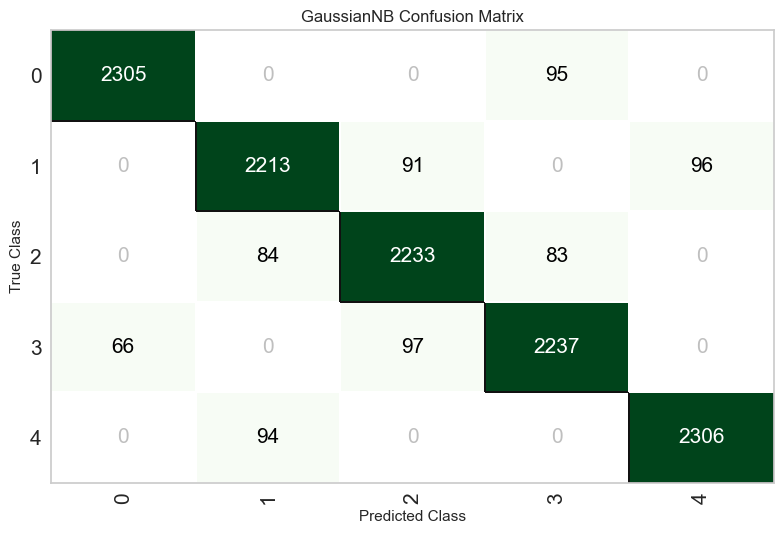

In [ ]:
plot_model(model, plot='confusion_matrix')

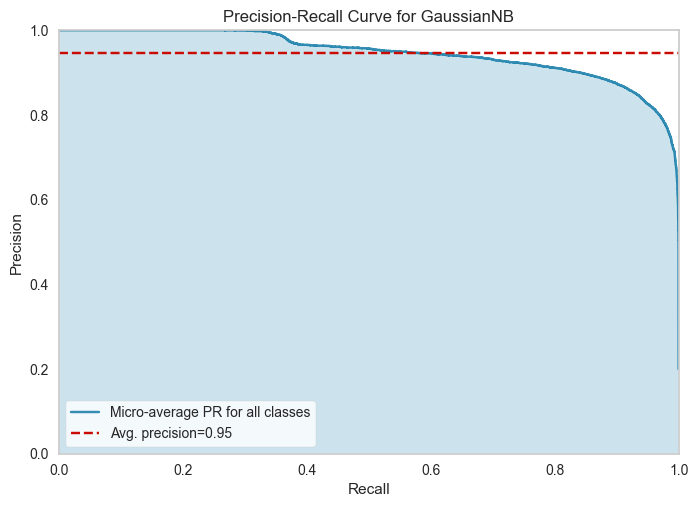

In [ ]:
# Generamos la curva Precision-Recall del modelo entrenado.
plot_model(model, plot='pr')

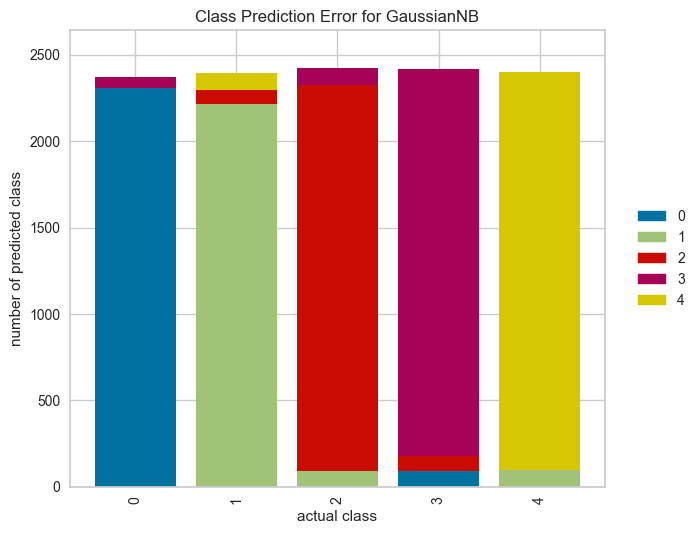

In [ ]:
# Generamos el gráfico de error del modelo entrenado.
plot_model(model, plot='error')